In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw2-task2.ipynb")

# Homework 2 - Task 2: Classification 
## Predicting High Asthma Prevalence : Do Social and Economic Conditions Predict Whether a Community Has Elevated Asthma Risk?

---

### Background

The **CDC/ATSDR Environmental Justice Index (EJI)** measures the cumulative environmental and social burdens faced by communities across the United States at the census-tract level. It combines three modules:

- **Environmental Burden Module (EBM)**: air quality, proximity to hazardous waste sites, impaired water bodies
- **Social Vulnerability Module (SVM)**: poverty, unemployment, race/ethnicity, housing conditions, health insurance
- **Health Vulnerability Module (HVM)**: prevalence of asthma, cancer, diabetes, mental illness

Research consistently shows that communities with greater poverty, unemployment, and minority populations bear a disproportionate share of environmental health burdens — including elevated rates of asthma. But can we actually predict which census tracts are in the top tier of asthma prevalence using only social vulnerability indicators?

**Your goal** is to build and compare two binary classification models — **K-Nearest Neighbors (KNN)** and **Logistic Regression** — that predict whether a census tract falls in the **top third** of asthma prevalence nationally. You will use **5-fold cross-validation** to select the best KNN hyperparameter and compare the results of both models. 

---

### Download the data
Follow these instructions to obtain the data for this assignment: 
1. Navigate to [this link](https://www.atsdr.cdc.gov/place-health/php/eji/eji-data-download.html)
1. Select the 2024 dropdown for the United States. 
2. **Choose the CSV File Type, and then click "Go"**. 
3. Add your data to the `task2/` folder. Your fle path should look like this for the autograder to run: `task2/EJI_2024_United_States.csv`. 
3. Don't forget to add your data to your `gitignore`! 


### Dataset 
Each row is a **U.S. census tract**. The variables used in this assignment are:

#### Response Variable

| Column | Description |
|---|---|
| `F_ASTHMA` | **Binary flag** — equals `1` if the tract's asthma prevalence percentile rank (`EPL_ASTHMA`) is above the 66th percentile, `0` otherwise |

#### Predictor Variables

| Column | Description | 
|---|---|
| `EPL_POV200` | Percentile rank for the share of residents below 200% of the federal poverty level | 
| `EPL_UNEMP` | Percentile rank for the civilian unemployment rate |
| `EPL_MINRTY` | Percentile rank for the share of residents identifying as a racial or ethnic minority | 

All three predictors are **percentile ranks** (0 = lowest burden, 1 = highest burden), so they are already on a comparable scale — no standardization is required.

### Setup: Load libraries and read in data

Run the cell below. It loads the EJI data, replaces the EPA missing-value (`-999`) with `NaN`, and takes a reproducible random sample of **10,000 tracts** so that cross-validated KNN runs in a reasonable time.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_curve, auc
)

# Load and clean
df_raw = pd.read_csv('task2/EJI_2024_United_States.csv')
df_raw = df_raw.replace(-999, np.nan)

# Reproducible 10,000-tract sample
df = df_raw.sample(n=10_000, random_state=42).reset_index(drop=True)
df.head(3)

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,GEOID_2020,COUNTY,StateDesc,STATEABBR,LOCATION,...,E_AIAN,NHPI,E_NHPI,TWOMORE,E_TWOMORE,OTHERRACE,E_OTHERRACE,Tribe_PCT_Tract,Tribe_Names,Tribe_Flag
0,72,21,31023,140000US72021031023,72021031023,72021031023,Bayamón Municipio,Puerto Rico,PR,Census Tract 310.23; Bayamón Municipio; Puerto...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-999,NaN
1,51,810,46400,140000US51810046400,51810046400,51810046400,Virginia Beach city,Virginia,VA,Census Tract 464; Virginia Beach city; Virginia,...,0.2,0.0,0.0,125.0,2.2,0.0,0.0,0.000000,-999,NaN
2,30,47,940600,140000US30047940600,30047940600,30047940600,Lake County,Montana,MT,Census Tract 9406; Lake County; Montana,...,26.6,6.0,0.1,420.0,8.6,3.0,0.1,99.994102,Flathead Reservation,1.0


<!-- BEGIN QUESTION -->

---
## Step 1: Explore Class Balance / Imbalance in Response Variable

Before building any model, we need to understand the distribution of our response variable `F_ASTHMA`. This is a binary flag that equals **1** if a census tract's asthma prevalence percentile rank is above the 66th percentile and **0** otherwise.

An imbalanced dataset — where one class appears far more often than the other — can mislead accuracy-based metrics and cause models to favor the majority class. Visualizing class counts first helps us anticipate this.

Create a bar chart of our binary response variable, `F_ASTHMA`. Be sure to include a title, x and y axis labels, and update from the default color. 

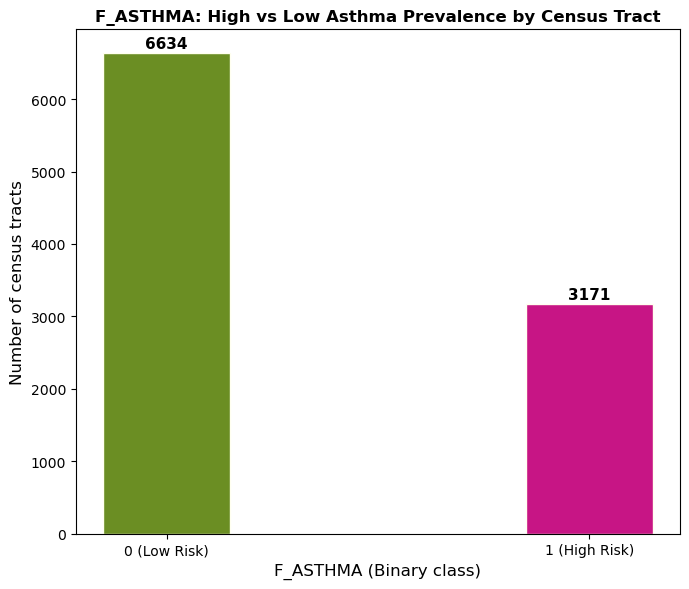

In [19]:
# Count occurrences of each class in the binary response variable
class_counts = df['F_ASTHMA'].value_counts().sort_index()

# Create bar chart to visualize class distribution
fig, ax = plt.subplots(figsize=(7, 6))
ax.bar(['0 (Low Risk)', '1 (High Risk)'], class_counts.values,
       color=['Olivedrab', 'mediumvioletred'], edgecolor='ivory', width=0.3)

# Add count labels on top of bars for readability
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 30, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('F_ASTHMA (Binary class)', fontsize=12)
ax.set_ylabel('Number of census tracts', fontsize=12)
ax.set_title('F_ASTHMA: High vs Low Asthma Prevalence by Census Tract', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

> **Q1:** Describe the class balance / imbalance. If there is an imbalance, how might it affect our classification algorithm? 

The dataset is moderately imbalanced.

The data has about twice as many low risk tracts (67%) asthan the high risk ones (33%). This means if a model always guesses "low risk", it would be right 67% of the time, without actually learning anything. Because of this imbalance, overall accuracy can be misleading. So we should also look at precision, recall and F1 score to get a fuller picture of how well the model is really doing.

<!-- END QUESTION -->

---
## Step 2: Prepare Features for Modeling

Complete the following steps:

1. Create a dataframe called `df_model` that contains the following predictor variables: `EPL_POV200`, `EPL_UNEMP`, and `EPL_MINRTY`, and your response variable: `F_ASTHMA`.
2. Drop any rows in `df_model` with NAs. `KNeighborsClassifier` doesn't allow any NAs.
3. Create a variable `X` containing your predictors, and `y` containing your response variable.
4. Split into 70% train / 30% test using `train_test_split` with `stratify=y` and `random_state=42`. Store as `X_train`, `X_test`, `y_train`, `y_test`.

Because all three predictors are already percentile ranks on a 0–1 scale, features won't dominate KNN distances due to differing units, so no standardization step is needed.

In [26]:
# Select only the relevant predictor and response columns
df_model = df[['EPL_POV200', 'EPL_UNEMP', 'EPL_MINRTY', 'F_ASTHMA']].copy()

# Drop rows with any missing values (KNN cannot handle NaN)
df_model = df_model.dropna()

# Separate predictors (X) as a numpy array and response (y) as a Series
X = df_model[['EPL_POV200', 'EPL_UNEMP', 'EPL_MINRTY']].values # Three social vulnerability percentile ranks used to predict high asthma risk
y = df_model['F_ASTHMA']

# Stratified 70/30 train-test split preserves class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

print(f'Training set : {X_train.shape[0]:,} tracts')
print(f'Test set     : {X_test.shape[0]:,} tracts')

Training set : 6,813 tracts
Test set     : 2,920 tracts


In [27]:
grader.check("q3")

q3 results: All test cases passed!

---
## Step 3: Fit a K-Nearest Neighbors Classifier (k = 3)

As a starting point, fit a `KNeighborsClassifier` with `n_neighbors=3` on the training data. Store the fitted model in `knn3`, predictions on the test set in `y_pred_knn3`, and test-set accuracy in `knn3_accuracy`.

**sklearn workflow reminder:**
```python
model = SomeClassifier(...)        # 1. initialize
model.fit(X_train, y_train)        # 2. fit on training data
y_pred = model.predict(X_test)     # 3. predict on test data
acc = accuracy_score(y_test, y_pred)  # 4. evaluate
```
We'll use k = 3 here as a baseline, then use cross-validation in Step 4 to find the optimal k.

In [28]:
# Initialize KNN classifier with k=3 as a baseline
knn3 = KNeighborsClassifier(n_neighbors=3)

# Fit on training data
knn3.fit(X_train, y_train)

# Generate predictions on the held-out test set
y_pred_knn3 = knn3.predict(X_test)

# Evaluate with overall accuracy
knn3_accuracy = accuracy_score(y_test, y_pred_knn3)

print(f'KNN (K=3) test accuracy: {knn3_accuracy:.4f}')

KNN (K=3) test accuracy: 0.7418


In [29]:
grader.check("q4")

q4 results: All test cases passed!

---
## Step 4: Selecting K with 5-Fold Cross-Validation

Choosing K by checking accuracy on a single test split is risky because the result depends on which observations land in the test set. **Cross-validation** gives a more reliable estimate by rotating through multiple train splits on the training data, leaving the test set untouched.

Using `cross_val_score` with `cv=5`, compute the **mean** and **standard deviation** of the 5-fold cross-validation overall accuracy on the **training set** for each K from 1 to 20. Then:

1. Store the mean CV scores in `cv_mean_scores`. (a numpy array of length 20).
2. Plot mean CV accuracy.
3. Store the K with the **highest mean CV score** in `optimal_k` (smallest K in case of a tie) and that score in `best_cv_score`.

Once we have found the best value of K to use, we will run another KNN Model with the test data that hasn't been used to fit any model yet. 

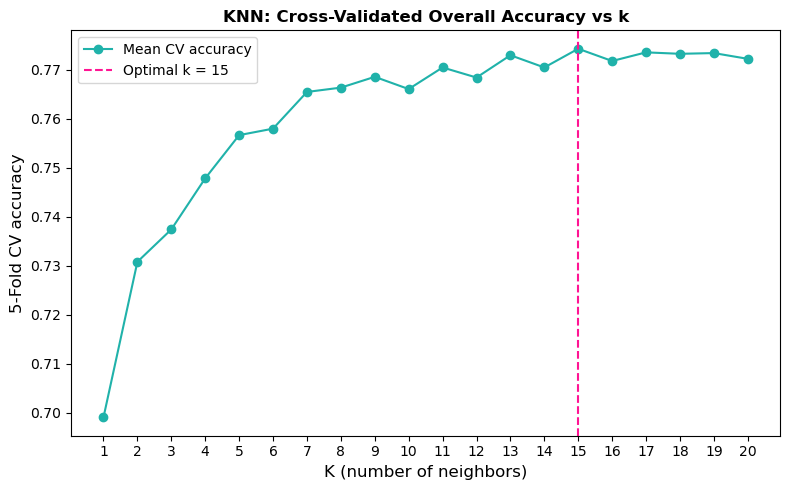

Optimal K = 15,  best mean CV accuracy = 0.7743


In [ ]:
# Candidate values of k to evaluate (1 through 20)
k_values = list(range(1, 21))

# Compute 5-fold CV mean accuracy on the training set for each candidate k
cv_mean_scores = np.array([
    cross_val_score(KNeighborsClassifier(n_neighbors=k), # `cross_val_score` rotates through 5 folds on X_train, the test set is never touched
                    X_train, y_train, cv=5).mean()
                    for k in k_values
])

# Select the k that yields the highest mean CV accuracy (argmax gives 0-based index)
optimal_k     = k_values[np.argmax(cv_mean_scores)]   # k=15
best_cv_score = cv_mean_scores.max()

# Visualize optimal k
fig, ax = plt.subplots(figsize=(8, 5))  
ax.plot(k_values, cv_mean_scores, marker='o', color='lightseagreen', linewidth=1.5, label='Mean CV accuracy')  
ax.axvline(optimal_k, color='deeppink', linestyle='--', label=f'Optimal k = {optimal_k}')  
ax.set_xlabel('K (number of neighbors)', fontsize=12)  
ax.set_ylabel('5-Fold CV accuracy', fontsize=12)  
ax.set_title('KNN: Cross-Validated Overall Accuracy vs k', fontsize=12, fontweight='bold') 
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))  
ax.legend()  
plt.tight_layout()  
plt.show()  

print(f'Optimal K = {optimal_k},  best mean CV accuracy = {best_cv_score:.4f}')

In [36]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2:** Why is using cross-validation to select K better than using the single test-set accuracy from Step 3? What would you e

Using cross-validation is better than using the single test-set accuracy because the result depends on which observations happen to land in that particular split, one unlucky split can make a bad K look good or a good K look bad. Cross-validation solves this by testing the model on 5 different folds of the training data and averaging the results, which gives a much more stable and trustworthy estimate of performance. It also keeps the test set completely untouched until the very end, so the final evaluation is fair. If we had used the test set to pick K, the accuracy might look better than it really is.

<!-- END QUESTION -->

---
## Step 5: KNN with Optimal K
 Re- run your  K-Nearest Neighbors Classifier with number of neighbors equal to  `optimal_k`. Store your accuracy in `knn_optimal_accuracy`.



In [37]:
# Refit KNN using the CV selected optimal k on the full training set
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train, y_train)

# Predict on the test set (first time test set is used for KNN evaluation)
y_pred_knn_optimal = knn_optimal.predict(X_test)

# Compute test-set accuracy for the optimally tuned KNN model
knn_optimal_accuracy = accuracy_score(y_test, y_pred_knn_optimal)

print(f'KNN (K={optimal_k}) test accuracy: {knn_optimal_accuracy:.4f}')

KNN (K=15) test accuracy: 0.7760


In [38]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->


> **Q3:** Compare the test-set accuracy of `knn3` (K = 3) and `knn_optimal` (K = `optimal_k`). Which performed better, and by how much? Why might the optimal K found by cross-validation outperform the arbitrary choice of K = 3?

KNN with K=3 achieved a test accuracy of 0.7418, while KNN with the CV-selected K=15 achieved 0.7760, a small but meaningful improvement. K=3 is more sensitive to noise because it only looks at 3 neighbors, so a single unusual data point can easily change the prediction. A larger K like 15 averages over more neighbors, which smooths out that noise and leads to more stable predictions. Cross-validation helped us find K=15 as the best choice, rather than just guessing K=3 arbitrarily.

<!-- END QUESTION -->

---
## Step 6: Logistic Regression with Cross-Validation


We will now create a Logistic Regression with the same predictors and outcome variable. 

1. Create a [`LogisticRegressionCV`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html) with `random_state=42` and `cv = 5`. Call it `lr`. The CV at the end of Logistic Regression is for cross fold validation. This allows you to use cross fold validation in your regression. 

>  Unlike plain [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression), LogisticRegressionCV automatically selects the best regularization strength C using 5-fold cross-validation. Regularization penalizes large coefficients to reduce overfitting; C controls how strong that penalty is. The cross-validation tries a range of C values and picks the one with the best average held-out accuracy across the 5 folds. 

2. Fit `lr` on the full training set, predict on the test set, and store predictions in `y_pred_lr` and test-set accuracy in `lr_accuracy`. This will be using the default threshold of $\alpha=0.5$.
3. Extract the coefficients from your linear regression with `.coef_[]` and `.intercept_[]`. Create a table with a feature and coefficient column to present your results. 

In [39]:
# Fit logistic regression with 5-fold cross-validation
lr = LogisticRegressionCV(random_state=42, cv=5) # Select best regularization strength, preventing the model from overfitting
lr.fit(X_train, y_train)  # Train the model on the training set

# Predict whether each test tract has high asthma risk (1) or not (0)
y_pred_lr = lr.predict(X_test)

# Measure how often the model correctly classifies tracts on the test set
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_accuracy

0.7753424657534247

In [40]:
# Extract model coefficients and intercept for interpretation
feature_names = ['EPL_POV200', 'EPL_UNEMP', 'EPL_MINRTY']
coefficients = lr.coef_[0]   # Coefficient is shape (1, n_features) for binary classification
intercept = lr.intercept_[0]

# Build a summary DataFrame for clean display
coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coefficients
})

print(f'Intercept: {intercept:.4f}\n')
print(coef_df.to_string(index=False))

Intercept: -3.3201

   Feature  Coefficient
EPL_POV200     5.008554
 EPL_UNEMP     0.891915
EPL_MINRTY    -1.379598


In [41]:
grader.check("q9")

q9 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q4:** Which predictors have a negative association with a tract being flagged for high asthma prevalence? Interpret one of them in plain 
  language,
>
> **Note:** Notice this is an inference question. In this case we are using only a subset of the training data to answer it for convenience, but the best practice is to use *all the available data* to investigate inference questions and use a *training/test data* splot for prediction.

`EPL_MINRTY` has a negative coefficient (≈ −1.38), which means that when poverty and unemployment are held constant, tracts with a higher minority population are actually *less* likely to be flagged for high asthma risk. This is surprising, but it may be because poverty and unemployment already capture most of the factors that drive asthma risk, leaving minority population with little additional explanatory power. It is also worth noting that we are only using three predictors on a random sample of 10,000 tracts, so the result should be interpreted with caution.

<!-- END QUESTION -->

---
## Step 7: Confusion Matrix for Logistic Regression

Compute the **confusion matrix** for the logistic regression predictions on the test set. Store the 2 x 2 numpy array in `cm_lr`. Plot it using `ConfusionMatrixDisplay` with display labels `['0', '1]'`.

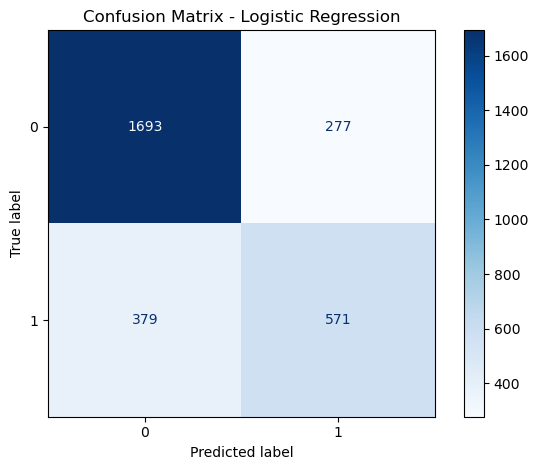

In [51]:
# Compute 2x2 confusion matrix (rows = actual, columns = predicted)
# Layout: [[TN, FP], [FN, TP]]
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Visualize using sklearn's built-in display with labeled axes
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['0', '1'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

In [46]:
grader.check("q11")

q11 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

From the confusion matrix: **True Negatives (TN) = 1693**, **False Positives (FP) = 277**, **False Negatives (FN) = 379**, **True Positives (TP) = 571**.

- **True Negatives (1693):** The model correctly predicted these tracts as low asthma risk, and they actually were low risk.
- **False Positives (277):** The model predicted these tracts as high asthma risk, but they were actually low risk. These are false alarms.
- **False Negatives (379):** The model predicted these tracts as low asthma risk, but they were actually high risk. This is the most concerning mistake because real high-risk communities are being missed.
- **True Positives (571):** The model correctly predicted these tracts as high asthma risk, and they actually were high risk.

<!-- END QUESTION -->

---
## Step 8: Accuracy Metrics for Logistic Regression

 Calculate accuracy, precision, recall, and the F1 score. Store your results in `accuracy_lr`, `precision_lr`, `recall_lr`, and `f1_lr` with the functions from `sklearn.metrics`.

In [47]:
# Compute four standard classification metrics using sklearn.metrics functions

# Accuracy: proportion of all predictions (both classes) that are correct
accuracy_lr = accuracy_score(y_test, y_pred_lr)

# Precision: of all tracts flagged high-risk, what fraction truly are? (reduces false alarms)
precision_lr = precision_score(y_test, y_pred_lr)

# Recall (Sensitivity): of all truly high-risk tracts, what fraction did we catch? (reduces missed cases)
recall_lr = recall_score(y_test, y_pred_lr)

# F1 Score: harmonic mean of precision and recall, balances both concerns
f1_lr = f1_score(y_test, y_pred_lr)

print(f'Accuracy  = {accuracy_lr:.4f}')
print(f'Precision = {precision_lr:.4f}')
print(f'Recall    = {recall_lr:.4f}')
print(f'F1 Score  = {f1_lr:.4f}')

Accuracy  = 0.7753
Precision = 0.6733
Recall    = 0.6011
F1 Score  = 0.6352


In [48]:
grader.check("q13")

q13 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q6:** Compare the accuracy, precision, recall, and F1 score for the logistic regression model. In the context of predicting high asthma risk tracts, which metric do you think is most important, and why? What is the trade-off between precision and recall here?

The model correctly classifies **77.5%** of all tracts overall. However, when it comes to identifying high-risk tracts specifically:
- It is correct **67.3%** of the time when it flags a tract as high risk (precision).
- It only catches **60.1%** of all truly high-risk tracts (recall).
- The F1 score of **0.635** reflects this imbalance. The model is decent overall but struggles to reliably identify high-risk communities.

In the context of predicting high asthma risk tracts, recall is the most important metric here. In a public health context, missing a truly high-risk tract is the worst mistake the model can make, that community needs help but gets none. A false alarm (flagging a low-risk tract as high risk) wastes some resources, but missing a high-risk tract has real consequences for people's health. So we want the model to catch as many high-risk tracts as possible.

The trade-off between precision and recall here is that if we want to catch more high-risk tracts (higher recall), the model will also flag more low-risk tracts by mistake (lower precision). On the other hand, if we want the model to only flag tracts it is very confident about (higher precision), it will end up missing more truly high-risk tracts (lower recall). In this case, since missing high-risk communities is more costly than a false alarm, we should lean toward higher recall even if it means lower precision.

<!-- END QUESTION -->

---
## Step 9: Confusion Matrix and Accuracy Metrics for KNN

Compute and plot the confusion matrix  for the **KNN (K = `optimal_k`)** model. Then calculate precision, recall, and F1 score. This lets you directly compare it to logistic regression beyond just overall accuracy.

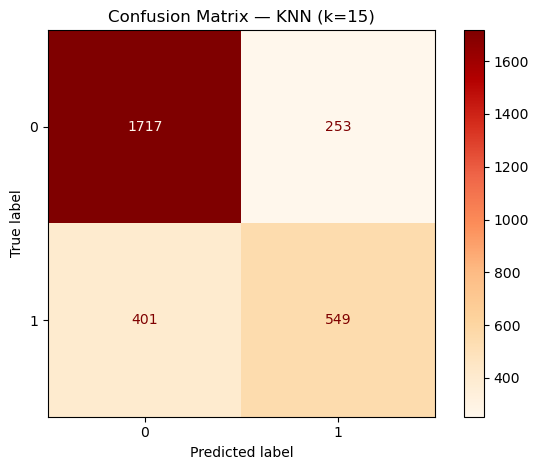

KNN (k=15) Confusion Matrix:
[[1717  253]
 [ 401  549]]

Precision (KNN): 0.6845
Recall    (KNN): 0.5779
F1 Score  (KNN): 0.6267

--- Model Comparison ---
              KNN (k=15)    Logistic Reg
Accuracy:     0.7760         0.7753
F1 Score:     0.6267         0.6352


In [50]:

# Compute confusion matrix for the optimal KNN model
cm_knn = confusion_matrix(y_test, y_pred_knn_optimal)

# Plot KNN confusion matrix for visual comparison with logistic regression
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['0', '1'])
disp_knn.plot(cmap='OrRd')
plt.title(f'Confusion Matrix — KNN (k={optimal_k})')
plt.tight_layout()
plt.show()

# Compute precision, recall and F1 for the optimal KNN model
precision_knn = precision_score(y_test, y_pred_knn_optimal)
recall_knn    = recall_score(y_test, y_pred_knn_optimal)
f1_knn        = f1_score(y_test, y_pred_knn_optimal)

print(f'KNN (k={optimal_k}) Confusion Matrix:\n{cm_knn}\n')
print(f'Precision (KNN): {precision_knn:.4f}')
print(f'Recall    (KNN): {recall_knn:.4f}')
print(f'F1 Score  (KNN): {f1_knn:.4f}')
print()
print('--- Model Comparison ---')
print(f'              KNN (k={optimal_k})    Logistic Reg')
print(f'Accuracy:     {knn_optimal_accuracy:.4f}         {lr_accuracy:.4f}')
print(f'F1 Score:     {f1_knn:.4f}         {f1_lr:.4f}')

In [ ]:
grader.check("q15")

<!-- BEGIN QUESTION -->

> **Q6:** Comment on the results of the Logistic Regression vs KNN. How do they compare in terms of performance? Which model would you pick? Why?

Both models perform similarly in terms of overall accuracy. KNN at 77.6% and Logistic Regression at 77.5%. The real difference shows up when we look at how well each model catches high-risk tracts.

KNN is more cautious. It only flags a tract as high risk when it is fairly confident, so its precision is slightly higher (0.685 vs 0.673). But because of this, it misses more truly high-risk tracts, with a recall of 0.578 compared to Logistic Regression's 0.601.

I would pick logistic regression. It catches more high-risk tracts, which is what matters most in a public health setting. It also lets us look at the coefficients to understand which factors are driving the predictions, making it easier to explain and act on the results.

<!-- END QUESTION -->

---
## Step 10: ROC Curve and AUC — Logistic Regression

The **Receiver Operating Characteristic (ROC)** curve plots the **True Positive Rate (Recall)** against the **False Positive Rate** across every possible classification threshold — not just the default 0.5 cutoff. This lets us see how the model trades off between catching more high-risk tracts (higher recall) and generating more false alarms (higher FPR).


Follow these steps:

1. **Get predicted probabilities.** Use `lr.predict_proba(X_test)` to get the predicted probability for each test observation. This returns a 2-column array — column 0 is the probability of class 0 (low asthma risk), column 1 is the probability of class 1 (high asthma risk). Keep only the class 1 probabilities and store in `y_proba_lr`.

2. **Compute the ROC curve.** Call `roc_curve(y_test, y_proba_lr)`. It returns three arrays: `fpr` (false positive rates), `tpr` (true positive rates), and `thresholds` — one entry per decision threshold the model evaluated.

3. **Compute AUC.** Pass `fpr` and `tpr` to `auc()` and store the result in `roc_auc`.

4. **Plot the ROC curve.** Create a line plot with `fpr` on the x-axis and `tpr` on the y-axis. Add a dashed diagonal line from (0, 0) to (1, 1) to represent a random classifier. Include axis labels, a title, and a legend that displays the AUC value.

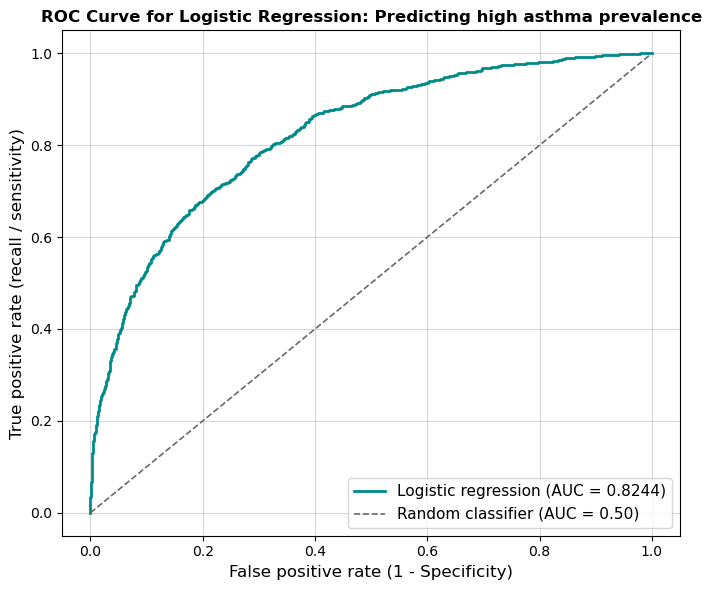

Logistic Regression AUC: 0.8244


In [56]:
# Get predicted class-1 (high asthma risk) probabilities from logistic regression
y_proba_lr = lr.predict_proba(X_test)[:, 1] # predict_proba returns a (n_samples, 2) array; column 1 = P(high risk)

# Compute ROC curve, sweeps every possible classification threshold
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)

# Compute Area under the ROC curve (AUC) [higher is better; 0.5 = random]
roc_auc = auc(fpr, tpr)

# Plot ROC curve with diagonal reference line for a random classifier
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='darkcyan', linewidth=2,
        label=f'Logistic regression (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='dimgrey', linestyle='--', linewidth=1.2,
        label='Random classifier (AUC = 0.50)')
ax.set_xlabel('False positive rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True positive rate (recall / sensitivity)', fontsize=12)
ax.set_title('ROC Curve for Logistic Regression: Predicting high asthma prevalence', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

print(f'Logistic Regression AUC: {roc_auc:.4f}')

In [57]:
grader.check("q17")

q17 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q7:** What does the AUC score tell you about the logistic regression model's ability to distinguish between high and low asthma risk tracts? Is this model meaningfully better than random guessing? How does the shape of the ROC curve reflect the precision-recall trade-off you observed in Step 8?

An AUC of 0.824 means that if we pick one high-risk tract and one low-risk tract at random, the model correctly ranks the high-risk tract as more likely to be high risk *82.4% of the time*. This is well above random guessing, which would give an AUC of 0.50, so the model is genuinely useful at telling the two groups apart.

Yes, the model is meaningfully better than random guessing. A random model would have no ability to distinguish high from low risk tracts, while this model gets it right more than 4 out of 5 times when comparing pairs.

The shape of the ROC curve shows the same trade-off we saw in Step 8. At one end, the model is very strict about flagging tracts as high risk, so it makes fewer mistakes but also misses more truly high-risk tracts. As we move along the curve and lower the threshold, it catches more high-risk tracts but also flags more low-risk ones by mistake, the same precision-recall trade-off we observed earlier.

<!-- END QUESTION -->



---

**Run the cell below to receive credit for autograded questions**

In [58]:
grader.check_all()

q11 results: All test cases passed!

q13 results: All test cases passed!

q15 results: All test cases passed!

q17 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q7 results: All test cases passed!

q9 results: All test cases passed!